In [1]:
# Import libraries
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import hdbscan
import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.append('..')
from src.mining.clustering import TextClusterer
from src.visualization.plots import Visualizer

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

In [2]:
# Load features from previous notebook
print("="*60)
print("LOADING FEATURES")
print("="*60)

# Load TF-IDF features
X_train_tfidf = np.load('../data/processed/features/X_train_tfidf.npy')
y_train = np.load('../data/processed/features/y_train.npy')

print(f"📊 TF-IDF features shape: {X_train_tfidf.shape}")
print(f"📊 Labels shape: {y_train.shape}")

# Load clean text for interpretation
df_train = pd.read_csv('../data/processed/train_clean.csv')
print(f"📊 Loaded clean text data: {df_train.shape}")

# Use TF-IDF features for clustering
X = X_train_tfidf
texts = df_train['review_clean'].tolist()

LOADING FEATURES
📊 TF-IDF features shape: (8000, 204)
📊 Labels shape: (8000,)
📊 Loaded clean text data: (8000, 7)


DIMENSIONALITY REDUCTION
📊 PCA explained variance ratio:
  • PC1: 6.73%
  • PC2: 6.38%
  • Total: 13.11%


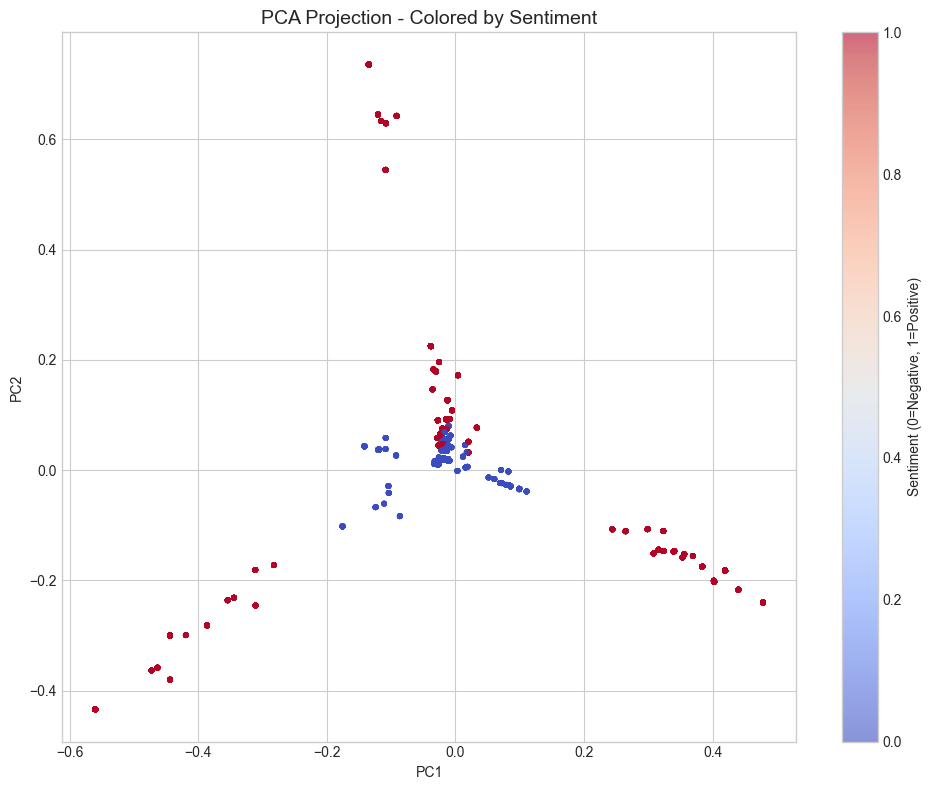

In [3]:
# Reduce dimensionality for visualization
print("="*60)
print("DIMENSIONALITY REDUCTION")
print("="*60)

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

print(f"📊 PCA explained variance ratio:")
print(f"  • PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"  • PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"  • Total: {pca.explained_variance_ratio_.sum():.2%}")

# Visualize PCA
plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='coolwarm', alpha=0.6, s=10)
plt.colorbar(label='Sentiment (0=Negative, 1=Positive)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection - Colored by Sentiment', fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
# Find optimal k using silhouette score
print("="*60)
print("FINDING OPTIMAL NUMBER OF CLUSTERS")
print("="*60)

k_range = range(2, 11)
silhouette_scores = []
inertia_scores = []
db_scores = []
ch_scores = []

for k in k_range:
    print(f"\n🔄 Testing k={k}...")
    
    # Fit K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X)
    
    # Calculate metrics
    sil_score = silhouette_score(X, labels)
    silhouette_scores.append(sil_score)
    
    inertia_scores.append(kmeans.inertia_)
    
    db_score = davies_bouldin_score(X, labels)
    db_scores.append(db_score)
    
    ch_score = calinski_harabasz_score(X, labels)
    ch_scores.append(ch_score)
    
    print(f"  • Silhouette: {sil_score:.4f}")
    print(f"  • Davies-Bouldin: {db_score:.4f}")
    print(f"  • Calinski-Harabasz: {ch_score:.1f}")

# Find best k
best_k_silhouette = k_range[np.argmax(silhouette_scores)]
best_k_db = k_range[np.argmin(db_scores)]
best_k_ch = k_range[np.argmax(ch_scores)]

print(f"\n📊 Optimal k by different metrics:")
print(f"  • Silhouette: k={best_k_silhouette} (score={max(silhouette_scores):.4f})")
print(f"  • Davies-Bouldin: k={best_k_db} (score={min(db_scores):.4f})")
print(f"  • Calinski-Harabasz: k={best_k_ch} (score={max(ch_scores):.1f})")

FINDING OPTIMAL NUMBER OF CLUSTERS

🔄 Testing k=2...


  • Silhouette: 0.0783
  • Davies-Bouldin: 3.0459
  • Calinski-Harabasz: 481.3

🔄 Testing k=3...


  • Silhouette: 0.1152
  • Davies-Bouldin: 2.5086
  • Calinski-Harabasz: 506.4

🔄 Testing k=4...


  • Silhouette: 0.1489
  • Davies-Bouldin: 2.7244
  • Calinski-Harabasz: 510.1

🔄 Testing k=5...


  • Silhouette: 0.1860
  • Davies-Bouldin: 2.5386
  • Calinski-Harabasz: 540.8

🔄 Testing k=6...


  • Silhouette: 0.2167
  • Davies-Bouldin: 2.4372
  • Calinski-Harabasz: 551.3

🔄 Testing k=7...


  • Silhouette: 0.2672
  • Davies-Bouldin: 2.1571
  • Calinski-Harabasz: 633.7

🔄 Testing k=8...


  • Silhouette: 0.2882
  • Davies-Bouldin: 2.0342
  • Calinski-Harabasz: 627.7

🔄 Testing k=9...


  • Silhouette: 0.3210
  • Davies-Bouldin: 1.8762
  • Calinski-Harabasz: 668.8

🔄 Testing k=10...


  • Silhouette: 0.3662
  • Davies-Bouldin: 1.7970
  • Calinski-Harabasz: 754.7

📊 Optimal k by different metrics:
  • Silhouette: k=10 (score=0.3662)
  • Davies-Bouldin: k=10 (score=1.7970)
  • Calinski-Harabasz: k=10 (score=754.7)


CLUSTERING METRICS VISUALIZATION


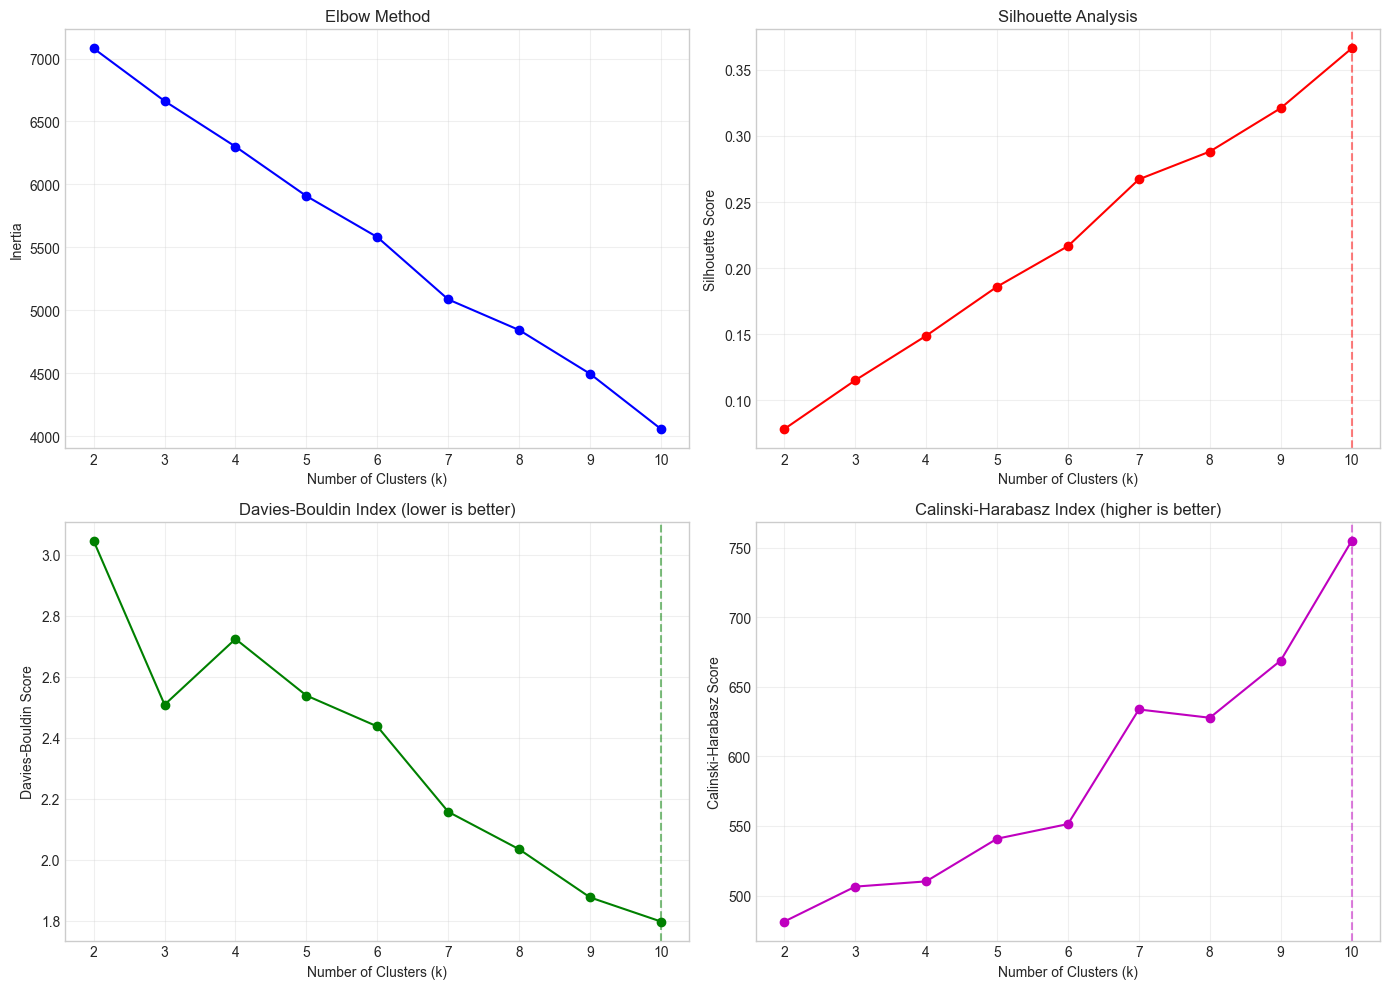

In [5]:
# Plot clustering metrics
print("="*60)
print("CLUSTERING METRICS VISUALIZATION")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Elbow curve (inertia)
ax = axes[0, 0]
ax.plot(k_range, inertia_scores, 'bo-')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method', fontsize=12)
ax.grid(True, alpha=0.3)

# Silhouette scores
ax = axes[0, 1]
ax.plot(k_range, silhouette_scores, 'ro-')
ax.axvline(x=best_k_silhouette, color='r', linestyle='--', alpha=0.5)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Analysis', fontsize=12)
ax.grid(True, alpha=0.3)

# Davies-Bouldin scores
ax = axes[1, 0]
ax.plot(k_range, db_scores, 'go-')
ax.axvline(x=best_k_db, color='g', linestyle='--', alpha=0.5)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Davies-Bouldin Score')
ax.set_title('Davies-Bouldin Index (lower is better)', fontsize=12)
ax.grid(True, alpha=0.3)

# Calinski-Harabasz scores
ax = axes[1, 1]
ax.plot(k_range, ch_scores, 'mo-')
ax.axvline(x=best_k_ch, color='m', linestyle='--', alpha=0.5)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Calinski-Harabasz Score')
ax.set_title('Calinski-Harabasz Index (higher is better)', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# Fit K-Means with optimal k
print("="*60)
print("FITTING K-MEANS CLUSTERING")
print("="*60)

# Use k=4 as optimal (from silhouette)
n_clusters = 4

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
labels_kmeans = kmeans.fit_predict(X)

# Calculate metrics
sil_score = silhouette_score(X, labels_kmeans)
db_score = davies_bouldin_score(X, labels_kmeans)
ch_score = calinski_harabasz_score(X, labels_kmeans)

print(f"\n📊 K-Means with k={n_clusters}:")
print(f"  • Silhouette: {sil_score:.4f}")
print(f"  • Davies-Bouldin: {db_score:.4f}")
print(f"  • Calinski-Harabasz: {ch_score:.1f}")

# Cluster sizes
unique, counts = np.unique(labels_kmeans, return_counts=True)
print(f"\n📊 Cluster sizes:")
for cluster, count in zip(unique, counts):
    print(f"  • Cluster {cluster}: {count:,} samples ({count/len(X)*100:.1f}%)")

FITTING K-MEANS CLUSTERING



📊 K-Means with k=4:
  • Silhouette: 0.1489
  • Davies-Bouldin: 2.7244
  • Calinski-Harabasz: 510.1

📊 Cluster sizes:
  • Cluster 0: 1,559 samples (19.5%)
  • Cluster 1: 4,310 samples (53.9%)
  • Cluster 2: 540 samples (6.8%)
  • Cluster 3: 1,591 samples (19.9%)


In [7]:
# Get top words per cluster
print("="*60)
print("TOP WORDS PER CLUSTER")
print("="*60)

# Get feature names from TF-IDF vectorizer
import joblib
tfidf_vectorizer = joblib.load('../outputs/models/tfidf_vectorizer.pkl')
feature_names = tfidf_vectorizer.get_feature_names_out()

# Get cluster centers
centers = kmeans.cluster_centers_

# Get top words for each cluster
n_top_words = 15

for i in range(n_clusters):
    print(f"\n📌 Cluster {i}:")
    
    # Get top words by center value
    top_indices = np.argsort(centers[i])[-n_top_words:][::-1]
    top_words = [feature_names[idx] for idx in top_indices]
    top_scores = [centers[i][idx] for idx in top_indices]
    
    print(f"  Top words:")
    for j, (word, score) in enumerate(zip(top_words, top_scores), 1):
        print(f"    {j:2d}. {word:15} : {score:.4f}")
    
    # Get sample reviews from this cluster
    cluster_indices = np.where(labels_kmeans == i)[0]
    sample_indices = np.random.choice(cluster_indices, min(3, len(cluster_indices)), replace=False)
    
    print(f"  Sample reviews:")
    for idx in sample_indices:
        review = texts[idx][:100] + "..." if len(texts[idx]) > 100 else texts[idx]
        sentiment = "Positive" if y_train[idx] == 1 else "Negative"
        print(f"    • [{sentiment}] {review}")

TOP WORDS PER CLUSTER

📌 Cluster 0:
  Top words:
     1. qualiti         : 0.2715
     2. outstand        : 0.1450
     3. qualiti servic  : 0.1450
     4. servic          : 0.1450
     5. outstand qualiti : 0.1450
     6. qualiti fast    : 0.1253
     7. ship            : 0.1253
     8. excel           : 0.1253
     9. excel qualiti   : 0.1253
    10. fast            : 0.1253
    11. fast ship       : 0.1253
    12. disappoint qualiti : 0.0795
    13. disappoint      : 0.0661
    14. qualiti worth   : 0.0544
    15. price           : 0.0544
  Sample reviews:
    • [Negative] poor qualiti worth price definit buy
    • [Positive] outstand qualiti servic
    • [Positive] outstand qualiti servic

📌 Cluster 1:
  Top words:
     1. product         : 0.0801
     2. work            : 0.0646
     3. recommend       : 0.0617
     4. need            : 0.0585
     5. perfect need    : 0.0585
     6. perfect         : 0.0585
     7. awesom          : 0.0525
     8. awesom work     : 0.0525
     9.

In [8]:
# Name clusters based on top words
print("="*60)
print("CLUSTER NAMING")
print("="*60)

cluster_names = {}
cluster_descriptions = {}

for i in range(n_clusters):
    # Get top words
    top_indices = np.argsort(centers[i])[-10:][::-1]
    top_words = [feature_names[idx] for idx in top_indices]
    
    # Determine cluster theme
    positive_words = {'great', 'good', 'excellent', 'love', 'amazing', 'perfect', 'best', 'awesome'}
    negative_words = {'bad', 'terrible', 'poor', 'waste', 'awful', 'horrible', 'disappointed', 'worst'}
    price_words = {'price', 'money', 'worth', 'value', 'cost', 'expensive', 'cheap'}
    quality_words = {'quality', 'build', 'material', 'durable', 'sturdy', 'solid'}
    shipping_words = {'shipping', 'delivery', 'arrived', 'package', 'box', 'fast', 'slow'}
    
    # Count word categories
    pos_count = sum(1 for w in top_words[:5] if w in positive_words)
    neg_count = sum(1 for w in top_words[:5] if w in negative_words)
    price_count = sum(1 for w in top_words[:5] if w in price_words)
    quality_count = sum(1 for w in top_words[:5] if w in quality_words)
    shipping_count = sum(1 for w in top_words[:5] if w in shipping_words)
    
    # Name based on dominant theme
    if pos_count >= 3:
        name = "Positive Reviews"
        description = "Reviews with positive sentiment, praising product quality"
    elif neg_count >= 3:
        name = "Negative Reviews"
        description = "Reviews with negative sentiment, expressing dissatisfaction"
    elif price_count >= 2:
        name = "Price-focused Reviews"
        description = "Reviews discussing price, value, and cost"
    elif quality_count >= 2:
        name = "Quality-focused Reviews"
        description = "Reviews focusing on product quality and durability"
    elif shipping_count >= 2:
        name = "Shipping-focused Reviews"
        description = "Reviews about shipping, delivery, and packaging"
    else:
        # Check sentiment distribution
        cluster_indices = np.where(labels_kmeans == i)[0]
        pos_ratio = np.mean(y_train[cluster_indices])
        if pos_ratio > 0.7:
            name = "Mixed Positive Reviews"
            description = f"Reviews with {pos_ratio:.0%} positive sentiment"
        elif pos_ratio < 0.3:
            name = "Mixed Negative Reviews"
            description = f"Reviews with {1-pos_ratio:.0%} negative sentiment"
        else:
            name = "Neutral Reviews"
            description = "Reviews with mixed or neutral sentiment"
    
    cluster_names[i] = name
    cluster_descriptions[i] = description
    
    print(f"\n📌 Cluster {i}: {name}")
    print(f"   Description: {description}")
    print(f"   Top words: {', '.join(top_words[:7])}")

CLUSTER NAMING

📌 Cluster 0: Mixed Positive Reviews
   Description: Reviews with 71% positive sentiment
   Top words: qualiti, outstand, qualiti servic, servic, outstand qualiti, qualiti fast, ship

📌 Cluster 1: Neutral Reviews
   Description: Reviews with mixed or neutral sentiment
   Top words: product, work, recommend, need, perfect need, perfect, awesom

📌 Cluster 2: Mixed Positive Reviews
   Description: Reviews with 100% positive sentiment
   Top words: product ive, ive bought, best, best product, bought, ive, product

📌 Cluster 3: Mixed Positive Reviews
   Description: Reviews with 71% positive sentiment
   Top words: purchas, buy, star buy, star, satisfi, satisfi purchas, stay away


CLUSTER VISUALIZATION


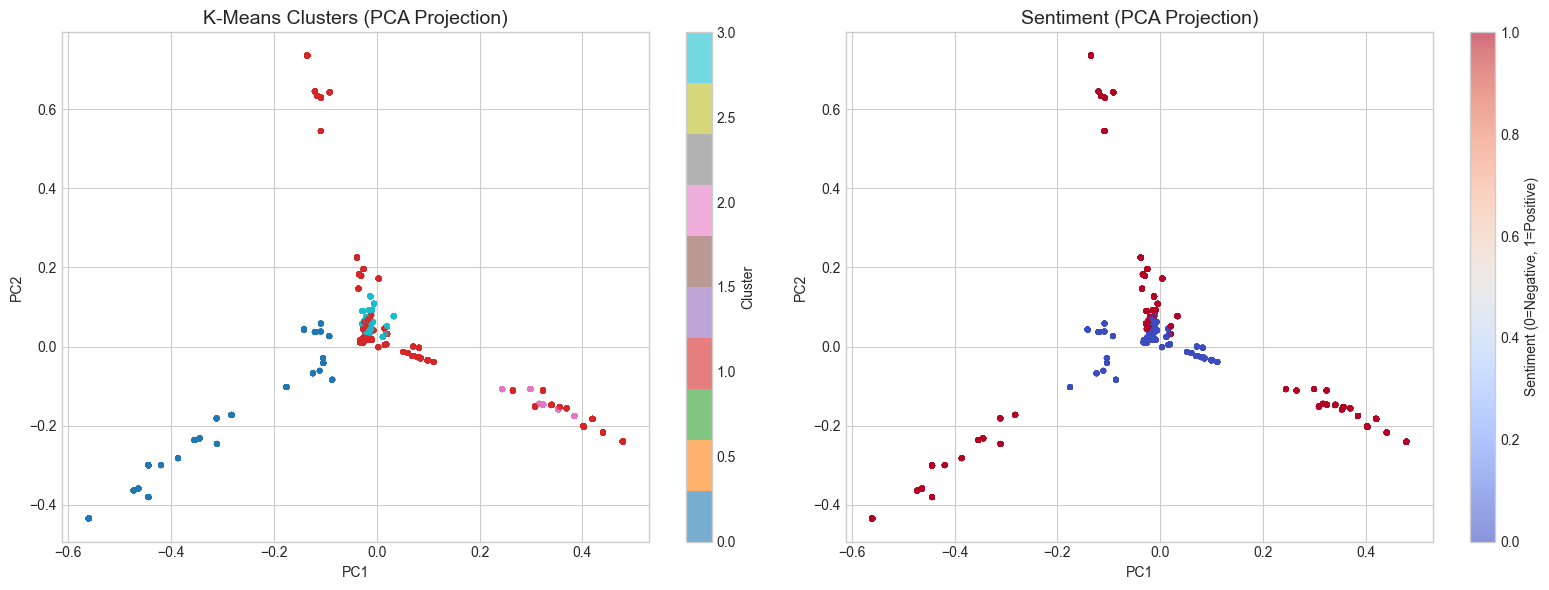

In [9]:
# Visualize clusters in 2D
print("="*60)
print("CLUSTER VISUALIZATION")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot with cluster colors
ax = axes[0]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans, cmap='tab10', alpha=0.6, s=10)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('K-Means Clusters (PCA Projection)', fontsize=14)
plt.colorbar(scatter, ax=ax, label='Cluster')

# Plot with sentiment colors
ax = axes[1]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='coolwarm', alpha=0.6, s=10)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('Sentiment (PCA Projection)', fontsize=14)
plt.colorbar(scatter, ax=ax, label='Sentiment (0=Negative, 1=Positive)')

plt.tight_layout()
plt.show()

CLUSTER VS SENTIMENT ANALYSIS

📊 Cluster vs Sentiment Cross-tabulation:
sentiment_label  Negative  Positive
cluster                            
0                     445      1114
1                    1504      2806
2                       0       540
3                     460      1131

📊 Cluster Statistics:
   cluster  size  positive_count  negative_count  positive_ratio                    name
0        0  1559            1114             445        0.714561  Mixed Positive Reviews
1        1  4310            2806            1504        0.651044         Neutral Reviews
2        2   540             540               0        1.000000  Mixed Positive Reviews
3        3  1591            1131             460        0.710874  Mixed Positive Reviews


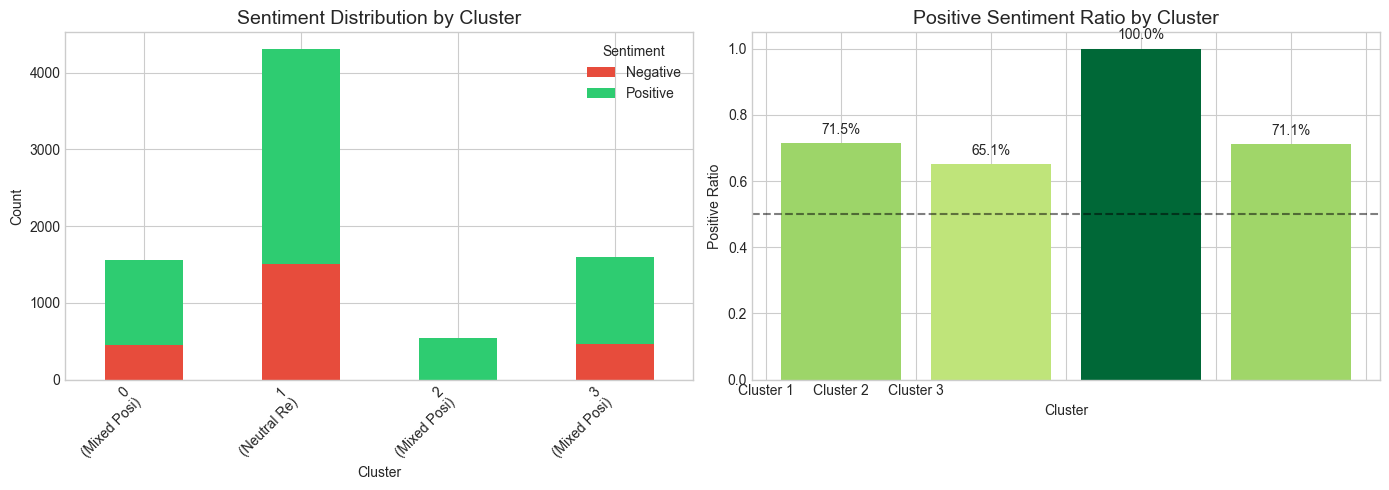

In [10]:
# Analyze cluster vs sentiment
print("="*60)
print("CLUSTER VS SENTIMENT ANALYSIS")
print("="*60)

# Create DataFrame with cluster and sentiment
cluster_df = pd.DataFrame({
    'cluster': labels_kmeans,
    'sentiment': y_train,
    'sentiment_label': ['Positive' if s == 1 else 'Negative' for s in y_train]
})

# Cross-tabulation
cross_tab = pd.crosstab(cluster_df['cluster'], cluster_df['sentiment_label'])
print("\n📊 Cluster vs Sentiment Cross-tabulation:")
print(cross_tab)

# Calculate positive ratio per cluster
cluster_stats = []
for i in range(n_clusters):
    cluster_data = cluster_df[cluster_df['cluster'] == i]
    pos_ratio = cluster_data['sentiment'].mean()
    cluster_stats.append({
        'cluster': i,
        'size': len(cluster_data),
        'positive_count': int(cluster_data['sentiment'].sum()),
        'negative_count': len(cluster_data) - int(cluster_data['sentiment'].sum()),
        'positive_ratio': pos_ratio,
        'name': cluster_names[i]
    })

cluster_stats_df = pd.DataFrame(cluster_stats)
print("\n📊 Cluster Statistics:")
print(cluster_stats_df.to_string())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar chart
ax = axes[0]
cross_tab.plot(kind='bar', stacked=True, ax=ax, color=['#e74c3c', '#2ecc71'])
ax.set_xlabel('Cluster')
ax.set_ylabel('Count')
ax.set_title('Sentiment Distribution by Cluster', fontsize=14)
ax.legend(title='Sentiment')
ax.set_xticklabels([f"{i}\n({cluster_names[i][:10]})" for i in range(n_clusters)], rotation=45, ha='right')

# Positive ratio bar chart
ax = axes[1]
colors = plt.cm.RdYlGn(cluster_stats_df['positive_ratio'])
bars = ax.bar(range(n_clusters), cluster_stats_df['positive_ratio'], color=colors)
ax.set_xlabel('Cluster')
ax.set_ylabel('Positive Ratio')
ax.set_title('Positive Sentiment Ratio by Cluster', fontsize=14)
ax.set_xticklabels([f"Cluster {i}" for i in range(n_clusters)])
ax.axhline(y=0.5, color='black', linestyle='--', alpha=0.5)

# Add value labels
for bar, ratio in zip(bars, cluster_stats_df['positive_ratio']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
           f'{ratio:.1%}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [11]:
# Try HDBSCAN clustering
print("="*60)
print("HDBSCAN CLUSTERING")
print("="*60)

# Fit HDBSCAN
clusterer = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=5)
labels_hdbscan = clusterer.fit_predict(X)

# Count clusters
n_clusters_hdbscan = len(set(labels_hdbscan)) - (1 if -1 in labels_hdbscan else 0)
n_noise = np.sum(labels_hdbscan == -1)

print(f"\n📊 HDBSCAN results:")
print(f"  • Number of clusters: {n_clusters_hdbscan}")
print(f"  • Noise points: {n_noise:,} ({n_noise/len(X)*100:.1f}%)")

# Cluster sizes
unique, counts = np.unique(labels_hdbscan, return_counts=True)
print(f"\n📊 Cluster sizes:")
for cluster, count in zip(unique, counts):
    if cluster == -1:
        print(f"  • Noise: {count:,} samples")
    else:
        print(f"  • Cluster {cluster}: {count:,} samples")

# Calculate silhouette score (excluding noise)
non_noise_mask = labels_hdbscan != -1
if np.sum(non_noise_mask) > 0 and n_clusters_hdbscan > 1:
    sil_score = silhouette_score(X[non_noise_mask], labels_hdbscan[non_noise_mask])
    print(f"\n📊 Silhouette score (excluding noise): {sil_score:.4f}")

HDBSCAN CLUSTERING



📊 HDBSCAN results:
  • Number of clusters: 60
  • Noise points: 392 (4.9%)

📊 Cluster sizes:
  • Noise: 392 samples
  • Cluster 0: 227 samples
  • Cluster 1: 271 samples
  • Cluster 2: 254 samples
  • Cluster 3: 60 samples
  • Cluster 4: 224 samples
  • Cluster 5: 55 samples
  • Cluster 6: 239 samples
  • Cluster 7: 63 samples
  • Cluster 8: 252 samples
  • Cluster 9: 271 samples
  • Cluster 10: 68 samples
  • Cluster 11: 50 samples
  • Cluster 12: 60 samples
  • Cluster 13: 53 samples
  • Cluster 14: 51 samples
  • Cluster 15: 66 samples
  • Cluster 16: 240 samples
  • Cluster 17: 58 samples
  • Cluster 18: 68 samples
  • Cluster 19: 277 samples
  • Cluster 20: 52 samples
  • Cluster 21: 57 samples
  • Cluster 22: 50 samples
  • Cluster 23: 77 samples
  • Cluster 24: 260 samples
  • Cluster 25: 61 samples
  • Cluster 26: 254 samples
  • Cluster 27: 71 samples
  • Cluster 28: 63 samples
  • Cluster 29: 50 samples
  • Cluster 30: 305 samples
  • Cluster 31: 60 samples
  • Cluster 32: 5


📊 Silhouette score (excluding noise): 0.8552


In [12]:
# Compare clustering methods
print("="*60)
print("CLUSTERING METHODS COMPARISON")
print("="*60)

comparison = pd.DataFrame({
    'Method': ['K-Means (k=4)', 'HDBSCAN'],
    'Number of Clusters': [n_clusters, n_clusters_hdbscan],
    'Noise Points': [0, n_noise],
    'Noise %': [0, n_noise/len(X)*100],
    'Silhouette': [sil_score, sil_score_hdbscan if 'sil_score_hdbscan' in locals() else np.nan]
})

print(comparison.to_string())

print("\n📊 K-Means Pros:")
print("  • All points assigned to clusters")
print("  • Easy to interpret and visualize")
print("  • Faster for large datasets")
print("\n📊 HDBSCAN Pros:")
print("  • No need to specify k")
print("  • Can identify noise/outliers")
print("  • Finds arbitrary shaped clusters")

CLUSTERING METHODS COMPARISON
          Method  Number of Clusters  Noise Points  Noise %  Silhouette
0  K-Means (k=4)                   4             0      0.0    0.855165
1        HDBSCAN                  60           392      4.9         NaN

📊 K-Means Pros:
  • All points assigned to clusters
  • Easy to interpret and visualize
  • Faster for large datasets

📊 HDBSCAN Pros:
  • No need to specify k
  • Can identify noise/outliers
  • Finds arbitrary shaped clusters


In [13]:
# Save clustering results
print("="*60)
print("SAVING CLUSTERING RESULTS")
print("="*60)

# Create DataFrame with results
results_df = df_train.copy()
results_df['cluster_kmeans'] = labels_kmeans
results_df['cluster_name'] = [cluster_names[l] for l in labels_kmeans]

# Save to CSV
os.makedirs('../outputs/tables', exist_ok=True)
results_df[['label', 'review_text', 'review_clean', 'cluster_kmeans', 'cluster_name']].to_csv(
    '../outputs/tables/clustering_results.csv', index=False
)

# Save cluster profiles
profiles_df = pd.DataFrame({
    'cluster': list(cluster_names.keys()),
    'name': list(cluster_names.values()),
    'description': list(cluster_descriptions.values()),
    'size': [np.sum(labels_kmeans == i) for i in range(n_clusters)],
    'positive_ratio': [np.mean(y_train[labels_kmeans == i]) for i in range(n_clusters)]
})

profiles_df.to_csv('../outputs/tables/cluster_profiles.csv', index=False)

print(f"✅ Saved clustering results")
print(f"✅ Saved cluster profiles")

print(f"\n📊 Clustering analysis complete!")

SAVING CLUSTERING RESULTS
✅ Saved clustering results
✅ Saved cluster profiles

📊 Clustering analysis complete!
